# Úkol 2


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

fs = 200
N = 100
f1 = 2
f2 = 8

Ts = 1 / fs
k = np.arange(N)
t = k * Ts

y = 5 * np.cos(2 * np.pi * f1 * k * Ts) - 2 * np.sin(2 * np.pi * f2 * k * Ts)

t_analog = np.linspace(0, (N-1)*Ts, 1000)
y_analog = 5 * np.cos(2 * np.pi * f1 * t_analog) - 2 * np.sin(2 * np.pi * f2 * t_analog)


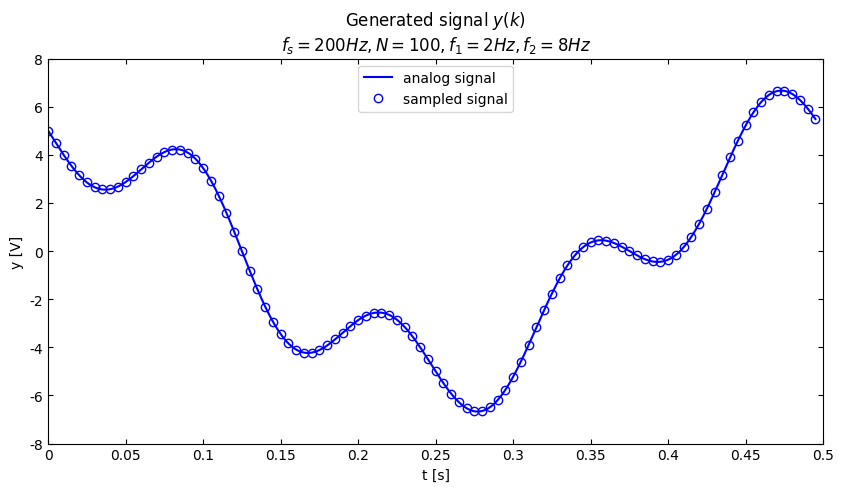

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_analog, y_analog, 'b-', label='analog signal')
ax.plot(t, y, 'bo', markerfacecolor='none', label='sampled signal')

title_y = r'Generated signal $y(k)$' + '\n' + r'$f_s=200Hz, N=100, f_1=2Hz, f_2=8Hz$'
ax.set_title(title_y)

ax.set_xlabel('t [s]')
ax.set_ylabel('y [V]')
ax.set_xlim(0, 0.5)
ax.set_ylim(-8, 8)

xticks = np.arange(0, 0.51, 0.05)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:g}" for x in xticks])

yticks = np.arange(-8, 9, 2)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{val:g}" for val in yticks])

ax.tick_params(direction='in', top=True, right=True, bottom=True, left=True)
ax.legend(loc='upper center')
plt.show()


In [3]:
y_mean_oa = np.sum(y) / N
y_mean_np = np.mean(y)

y_rms_oa = np.sqrt(np.sum(y**2) / N)
y_rms_np = np.sqrt(np.mean(y**2))

y_var_oa = np.sum((y - y_mean_oa)**2) / N
y_var_np = np.var(y)

y_std_oa = np.sqrt(y_var_oa)
y_std_np = np.std(y)

y_sorted = np.sort(y)
y_median_oa = (y_sorted[(N//2) - 1] + y_sorted[N//2]) / 2
y_median_np = np.median(y)

P_inst = y**2
P_inst_analog = y_analog**2

P_avg_oa = np.sum(y**2) / N
P_avg_np = np.mean(y**2)

E_oa = np.sum(y**2)
E_np = np.sum(y**2)

def format_table_value(val):
    if abs(val) < 1e-10:
        return "0"
    if abs(val) >= 100:
        return f"{int(round(val))}"
    if abs(val - round(val)) < 1e-10:
        return f"{int(round(val))}"
    return f"{val:.4f}"

data = {
    "": [
        "Mean value", 
        "RMS value", 
        "Variance",
        "Standard deviation", 
        "Median", 
        "Mean power (DSP)", 
        "Energy (DSP)"
    ],
    "Own algorithm": [
        y_mean_oa, 
        y_rms_oa, 
        y_var_oa, 
        y_std_oa, 
        y_median_oa, 
        P_avg_oa, 
        E_oa
    ],
    "Numpy command": [
        y_mean_np, 
        y_rms_np, 
        y_var_np, 
        y_std_np, 
        y_median_np, 
        P_avg_np, 
        E_np
    ],
    "Unit": [
        "V", 
        "V", 
        "V^2", 
        "V", 
        "V", 
        "V^2", 
        "V^2"
    ]
}

df = pd.DataFrame(data)

df["Own algorithm"] = df["Own algorithm"].apply(format_table_value)
df["Numpy command"] = df["Numpy command"].apply(format_table_value)

df_styled = df.style.hide(axis='index').set_properties(**{'text-align': 'center'}, subset=['']).set_properties(**{'text-align': 'right'}, subset=['Own algorithm', 'Numpy command']).set_properties(**{'text-align': 'left'}, subset=['Unit'])

display(df_styled)


,Own algorithm,Numpy command,Unit
Mean value,0,0,V
RMS value,3.8079,3.8079,V
Variance,14.5000,14.5000,V^2
Standard deviation,3.8079,3.8079,V
Median,0,0,V
Mean power (DSP),14.5000,14.5000,V^2
Energy (DSP),1450,1450,V^2


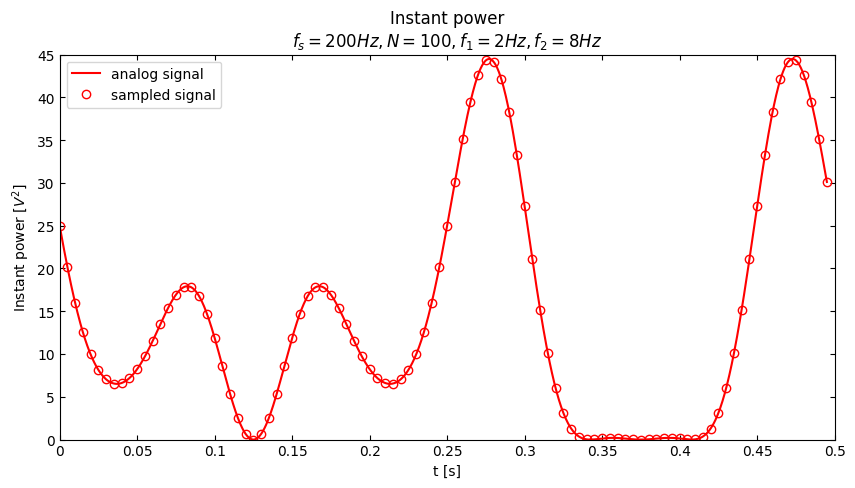

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_analog, P_inst_analog, 'r-', label='analog signal')
ax.plot(t, P_inst, 'ro', markerfacecolor='none', label='sampled signal')

title_p = r'Instant power' + '\n' + r'$f_s=200Hz, N=100, f_1=2Hz, f_2=8Hz$'
ax.set_title(title_p)

ax.set_xlabel('t [s]')
ax.set_ylabel('Instant power [$V^2$]')
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 45)

xticks = np.arange(0, 0.51, 0.05)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:g}" for x in xticks])

yticks = np.arange(0, 46, 5)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{val:g}" for val in yticks])

ax.tick_params(direction='in', top=True, right=True, bottom=True, left=True)
ax.legend(loc='upper left')
plt.show()


## Komentář

Nejprve jsem importoval nezbytné knihovny. Následně jsem definoval proměnné pro vzorkovací frekvenci f<sub>s</sub> = 200Hz, počet vzorků N = 100 a frekvence f<sub>1</sub> = 2Hz a f<sub>2</sub> = 8Hz. Z těchto parametrů jsem odvodil časový krok T<sub>s</sub> a vytvořil časový vektor k.

Signál y(k) jsem vygeneroval dle zadané rovnice y(k) = 5cos(2πf<sub>1</sub>kT<sub>s</sub>) − 2sin(2πf<sub>2</sub>kT<sub>s</sub>). Tento signál jsem zobrazil v modrém grafu, který kombinuje spojitou analogovou křivku s diskrétními vzorky.

K výpočtu charakteristik signálu jsem využil rovnice pro střední hodnotu, efektivní hodnotu (RMS), rozptyl, směrodatnou odchylku, medián, střední výkon a energii. Pro ověření správnosti jsem tyto hodnoty vypočítal také pomocí vestavěných funkcí knihovny numpy. Výsledky jsem uspořádal do přehledné tabulky, ve které lze ověřit, že jsou veškeré výpočty v obou verzích totožné.

Na závěr jsem vygeneroval a zobrazil průběh okamžitého výkonu P(k)=y<sup>2</sup>(k). Tento druhý signál je vykreslen v červeném grafu, který je stylován stejně, jako první modrý graf. Z grafu je patrné, že okamžitý výkon je vždy nezáporný a kmitá s dvojnásobnou frekvencí oproti původnímu signálu.
